# Notebook 02 — Emotion Classification

**Goal**: Run `cardiffnlp/twitter-roberta-base-emotion` on the cleaned tweets
to obtain per-tweet emotion probabilities (anger, fear, joy, sadness, surprise, disgust),
plus derived arousal and valence scores.

Sections:
1. Setup
2. Load cleaned tweets
3. Load model and run inference
4. Inspect predictions
5. Emotion distribution analysis
6. Export annotated dataset

In [2]:
# ── 1. Setup ──────────────────────────────────────────────────────────────
import sys, os

# Robust path: works whether notebook is run from repo root, notebooks/, or Colab
_nb_dir = os.path.dirname(os.path.abspath(globals().get("__file__", os.getcwd())))
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, "src")) else os.path.dirname(_nb_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.emotion_classifier import EmotionClassifier
from src.evaluation import EMOTION_COLORS

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# ── 2. Load cleaned tweets ────────────────────────────────────────────────
tweets = pd.read_csv(f"{OUTPUT_DIR}/tweets_cleaned.csv")
print(f"Loaded {len(tweets):,} tweets from {tweets['fixture_id'].nunique()} matches")
tweets[["fixture_id","window_5min","text_clean"]].head(5)

Loaded 14,474 tweets from 42 matches


,fixture_id,window_5min,text_clean
0,11867556,105,Record attendance and crowd noise at Bournemou...
1,11867556,110,Bournemouth take the lead as Calum Wilson acro...
2,11867556,110,You’d be forgiven for thinking that this was a...
3,11867556,110,Shit that’s a handball Bournemouth EPL Spurs
4,11867556,110,That was definitely a hand-ball but is that th...


In [4]:
# ── 3. Load model and run inference ──────────────────────────────────────
# NOTE: First run will download ~500 MB of model weights.
# On Colab: GPU recommended (Runtime → Change runtime type → T4 GPU)

clf = EmotionClassifier()  # auto-detects GPU

# Run on the full dataset (batched)
tweets = clf.predict_df(tweets, text_col="text_clean", batch_size=64)
print(f"Emotion columns added: {[c for c in tweets.columns if c in ['anger','fear','joy','sadness','surprise','disgust','arousal','valence','dominant_emotion']]}")
tweets.head(3)

[EmotionClassifier] Loading cardiffnlp/twitter-roberta-base-emotion on cpu ...


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

[EmotionClassifier] Labels: ['joy', 'optimism', 'anger', 'sadness']
Emotion columns added: ['joy', 'anger', 'sadness', 'dominant_emotion', 'arousal', 'valence']


,fixture_id,match,kickoff_utc,created_at,relative_minute_from_kickoff,window_5min,text,text_clean,polarity,home_team,away_team,derby,joy,optimism,anger,sadness,dominant_emotion,arousal,valence
0,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 18:49:49+00:00,109.816667,105,Record attendance and crowd noise at Bournemou...,Record attendance and crowd noise at Bournemou...,0.0000,AFC Bournemouth,Tottenham Hotspur,0,0.107820,0.814023,0.040629,0.037528,optimism,0.519838,0.033416
1,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 18:50:04+00:00,110.066667,110,Bournemouth take the lead as Calum Wilson acro...,Bournemouth take the lead as Calum Wilson acro...,0.0000,AFC Bournemouth,Tottenham Hotspur,0,0.156158,0.466945,0.240195,0.136703,optimism,0.594703,-0.207070
2,11867556,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,2020-07-09 18:50:23+00:00,110.383333,110,@CFCDaddy You’d be forgiven for thinking that ...,You’d be forgiven for thinking that this was a...,0.4389,AFC Bournemouth,Tottenham Hotspur,0,0.633695,0.094128,0.086372,0.185806,joy,0.550814,0.380098


In [5]:
# ── 4. Inspect predictions ────────────────────────────────────────────────
emotion_cols = [c for c in ["anger","fear","joy","sadness","surprise","disgust"] if c in tweets.columns]

print("Mean emotion probabilities across all tweets:")
print(tweets[emotion_cols].mean().round(4).to_string())
print(f"\nDominant emotion distribution:")
print(tweets["dominant_emotion"].value_counts().to_string())

Mean emotion probabilities across all tweets:
anger      0.1029
joy        0.3488
sadness    0.1267

Dominant emotion distribution:
dominant_emotion
optimism    7535
joy         4978
sadness     1316
anger        645


In [6]:
# Sample high-confidence predictions
for emo in emotion_cols[:4]:
    top = tweets.nlargest(1, emo)
    print(f"\nTop {emo} tweet (p={top[emo].values[0]:.3f}):")
    print(f'  "{top["text_clean"].values[0]}"')


Top anger tweet (p=0.932):
  "In a life of uncertainty, there are some things that are absolutely guaranteed. 👏👏 LCFC"

Top joy tweet (p=0.987):
  "i’m tired of liverpool fans shitting on naby keita. he’s been absolutely unconscious since the restart. and that was the exclamation. LFG. ynwa"

Top sadness tweet (p=0.985):
  "What has happened to us 😔 its sad. So much has to change cpfc"


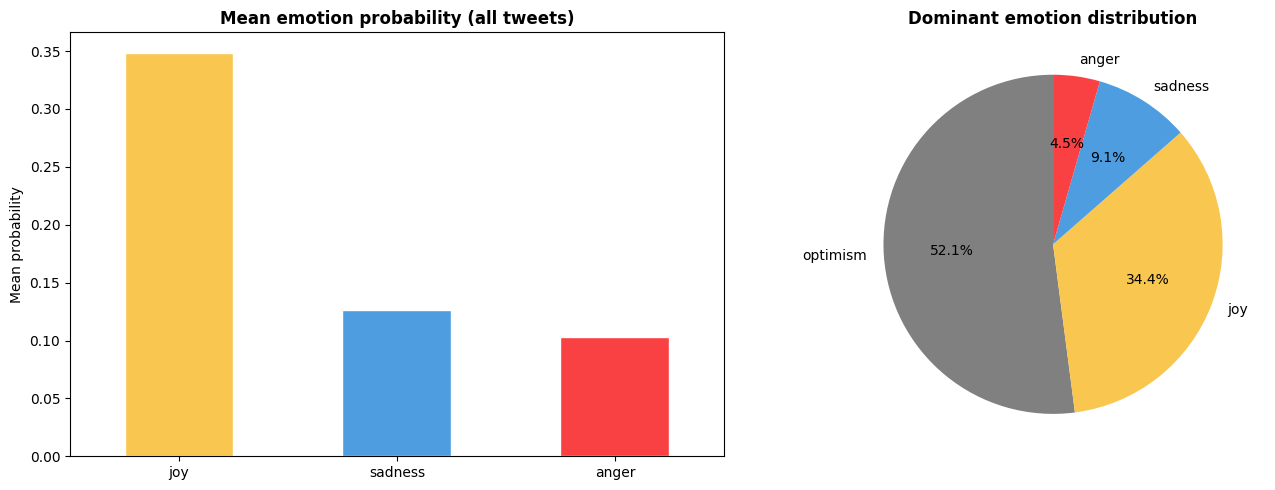

In [7]:
# ── 5. Emotion distribution analysis ─────────────────────────────────────
# (a) Overall distribution
mean_probs = tweets[emotion_cols].mean().sort_values(ascending=False)
colors = [EMOTION_COLORS.get(e, "grey") for e in mean_probs.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
mean_probs.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Mean emotion probability (all tweets)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Mean probability")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart of dominant emotion
dom_counts = tweets["dominant_emotion"].value_counts()
pie_colors = [EMOTION_COLORS.get(e, "grey") for e in dom_counts.index]
axes[1].pie(dom_counts.values, labels=dom_counts.index, colors=pie_colors,
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Dominant emotion distribution", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/emotion_distribution.png", dpi=150)
plt.show()

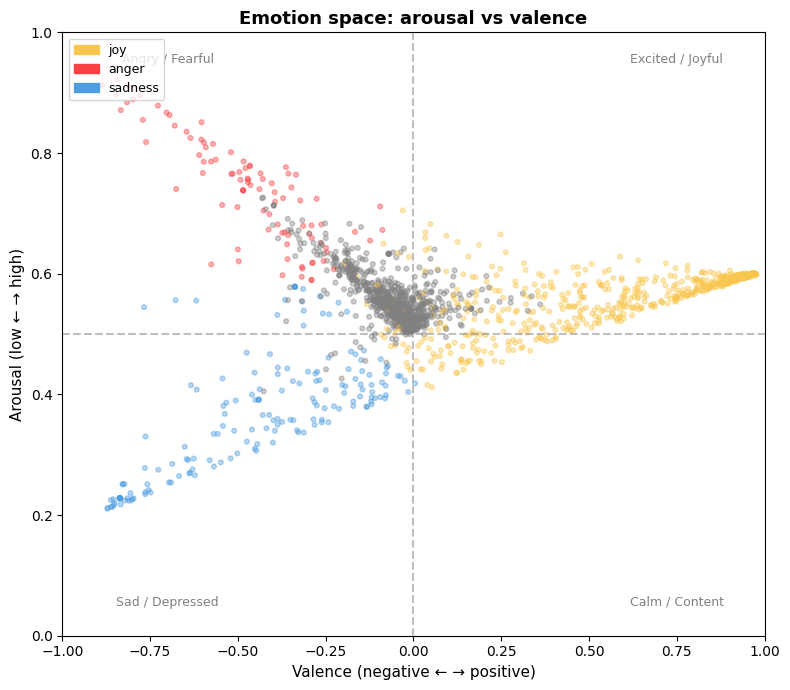

In [8]:
# (b) Arousal vs valence scatter
sample = tweets.sample(min(2000, len(tweets)), random_state=42)
colors_scatter = [EMOTION_COLORS.get(e, "grey") for e in sample["dominant_emotion"]]

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(sample["valence"], sample["arousal"], c=colors_scatter, alpha=0.4, s=12)

# Add legend manually
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=v, label=k) for k, v in EMOTION_COLORS.items() if k in tweets["dominant_emotion"].unique()]
ax.legend(handles=handles, loc="upper left", fontsize=9)

ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.axvline(0,   color="grey", linestyle="--", alpha=0.5)
ax.set_xlabel("Valence (negative ← → positive)", fontsize=11)
ax.set_ylabel("Arousal (low ← → high)", fontsize=11)
ax.set_title("Emotion space: arousal vs valence", fontsize=13, fontweight="bold")
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)

# Quadrant labels
ax.text(0.75, 0.95, "Excited / Joyful",  ha="center", fontsize=9, color="grey")
ax.text(-0.7, 0.95, "Angry / Fearful",   ha="center", fontsize=9, color="grey")
ax.text(0.75, 0.05, "Calm / Content",    ha="center", fontsize=9, color="grey")
ax.text(-0.7, 0.05, "Sad / Depressed",   ha="center", fontsize=9, color="grey")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/arousal_valence_scatter.png", dpi=150)
plt.show()

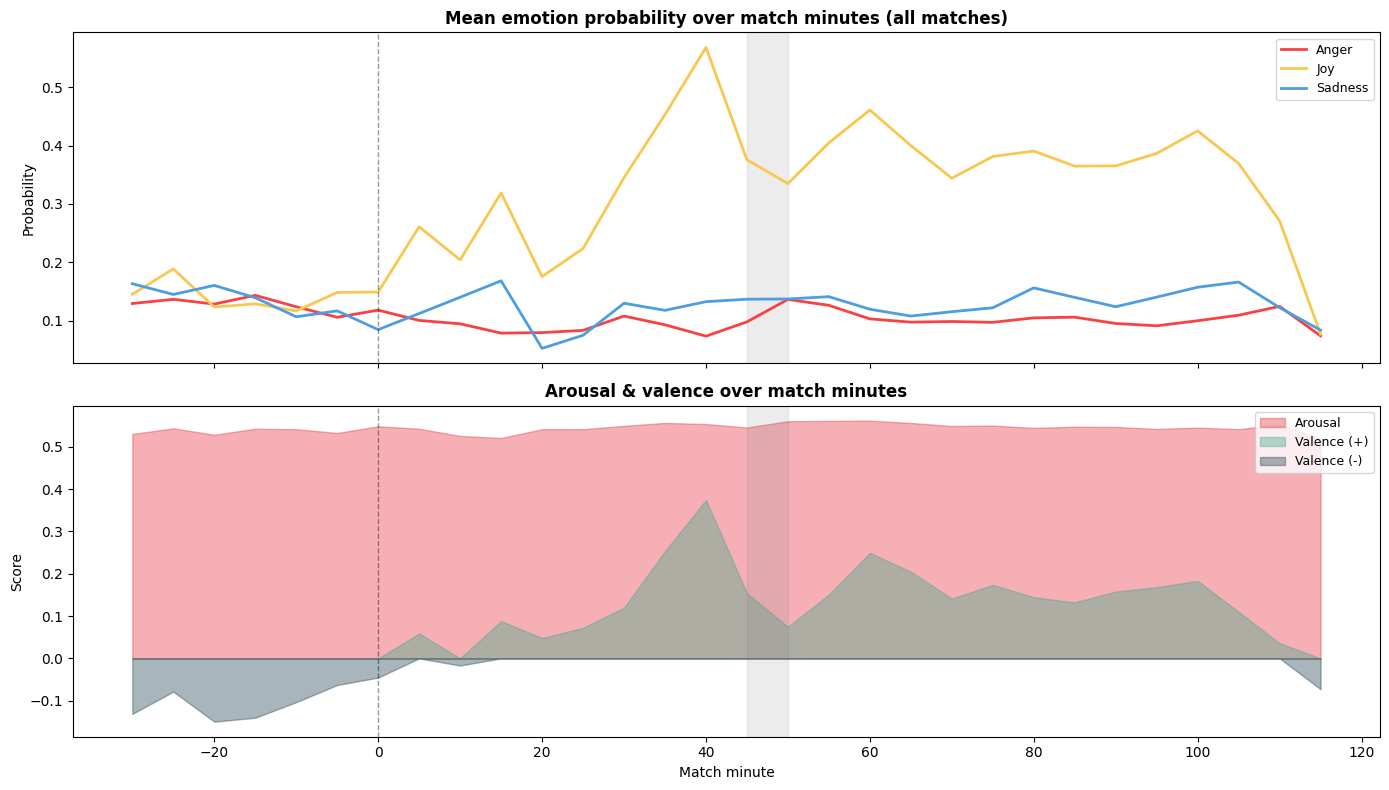

In [9]:
# (c) Emotion over match minutes (all matches pooled)
emotion_by_min = tweets.groupby("window_5min")[emotion_cols + ["arousal","valence"]].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for emo in emotion_cols:
    axes[0].plot(emotion_by_min.index, emotion_by_min[emo],
                 label=emo.capitalize(), color=EMOTION_COLORS.get(emo), linewidth=2)
axes[0].set_title("Mean emotion probability over match minutes (all matches)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Probability")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
axes[0].axvspan(45, 50, alpha=0.15, color="grey")

axes[1].fill_between(emotion_by_min.index, emotion_by_min["arousal"], alpha=0.4, color="#e63946", label="Arousal")
axes[1].fill_between(emotion_by_min.index, emotion_by_min["valence"].clip(0), alpha=0.4, color="#43aa8b", label="Valence (+)")
axes[1].fill_between(emotion_by_min.index, emotion_by_min["valence"].clip(upper=0), alpha=0.4, color="#264653", label="Valence (-)")
axes[1].set_title("Arousal & valence over match minutes", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Match minute")
axes[1].set_ylabel("Score")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
axes[1].axvspan(45, 50, alpha=0.15, color="grey")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/emotion_over_match_minutes.png", dpi=150)
plt.show()

In [10]:
# ── 6. Export ─────────────────────────────────────────────────────────────
tweets.to_csv(f"{OUTPUT_DIR}/tweets_with_emotions.csv", index=False)
print(f"Exported {len(tweets):,} annotated tweets → {OUTPUT_DIR}/tweets_with_emotions.csv")

Exported 14,474 annotated tweets → ../outputs/tweets_with_emotions.csv
